Searching element84_v1 for sentinel_s2_l2a...


Found 1 items.


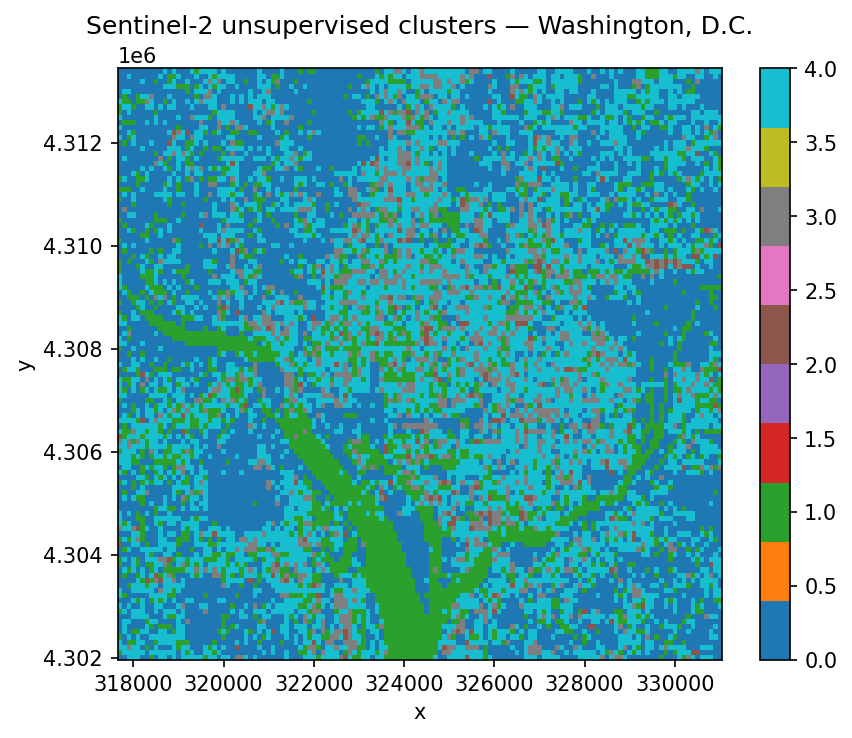

In [1]:
from geowombat.core.stac import open_stac
from geowombat.ml import fit_predict
from sklearn.cluster import MiniBatchKMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. Search Element 84's STAC catalog for Sentinel-2 scenes over D.C.
sentinel_scenes, scene_metadata = open_stac(
    stac_catalog="element84_v1",
    collection="sentinel_s2_l2a",
    bounds=(-77.1, 38.85, -76.95, 38.95),
    epsg=32618,
    bands=["blue", "green", "red", "nir"],
    start_date="2023-06-01",
    end_date="2023-07-31",
    cloud_cover_perc=20,
    resolution=100.0,
    chunksize=256,
    max_items=2,
    compute=True,
)

# 2. Define a one-step sklearn pipeline — MiniBatchKMeans for a fast unsupervised fit
unsupervised_kmeans_pipeline = Pipeline([
    ("kmeans", MiniBatchKMeans(n_clusters=5, random_state=0, n_init=3))
])

# 3. Classify a single date
first_scene = sentinel_scenes.isel(time=0)
cluster_map = fit_predict(data=first_scene, clf=unsupervised_kmeans_pipeline)

fig, ax = plt.subplots(dpi=150, figsize=(6, 5))
cluster_map.plot(robust=True, ax=ax, cmap="tab10")
ax.set_title("Sentinel-2 unsupervised clusters — Washington, D.C.")
plt.tight_layout(pad=1)
plt.show()

In [2]:
import geowombat as gw
from geowombat.data import l8_224078_20200518, l8_224078_20200518_polygons
from geowombat.ml import fit, predict, fit_predict
import geopandas as gpd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB

label_encoder = LabelEncoder()
training_polygons = gpd.read_file(l8_224078_20200518_polygons)
training_polygons["lc"] = label_encoder.fit(training_polygons.name).transform(
    training_polygons.name
)
training_polygons[["name", "lc", "geometry"]]

,name,lc,geometry
0,water,3,"POLYGON ((737544.502 -2795232.772, 737544.502 ..."
1,crop,0,"POLYGON ((742517.658 -2798160.232, 743046.717 ..."
2,tree,2,"POLYGON ((742435.36 -2801875.403, 742458.874 -..."
3,developed,1,"POLYGON ((738903.667 -2811573.845, 738926.586 ..."


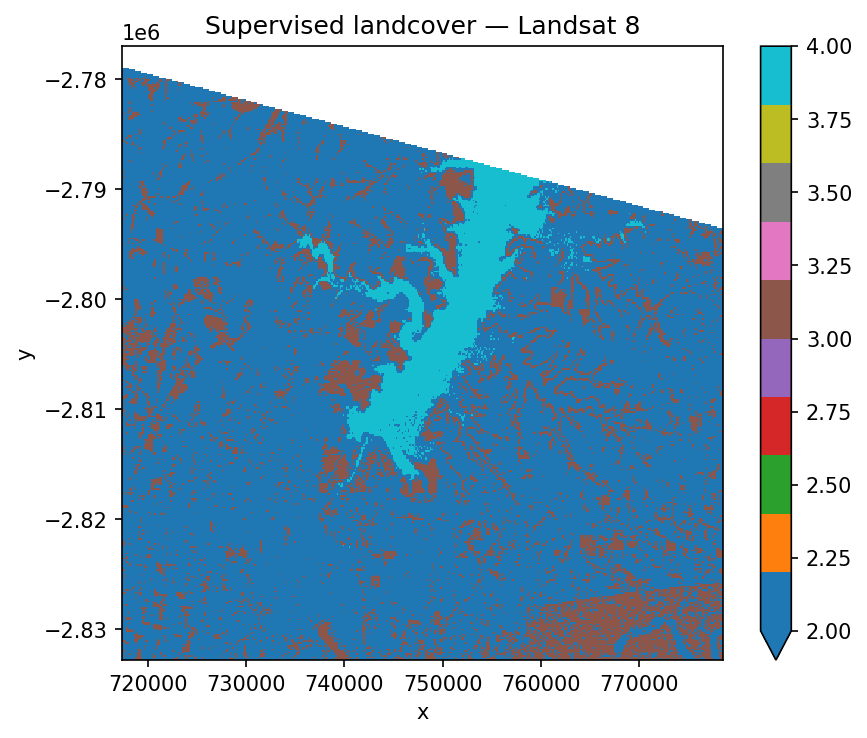

In [3]:
landcover_pipeline = Pipeline([
    ("scaler",     StandardScaler()),
    ("pca",        PCA()),
    ("classifier", GaussianNB()),
])

fig, ax = plt.subplots(dpi=150, figsize=(6, 5))
with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as landsat_scene:
        landcover_map = fit_predict(
            landsat_scene, landcover_pipeline, training_polygons, col="lc"
        )
        landcover_map.plot(robust=True, ax=ax, cmap="tab10")
ax.set_title("Supervised landcover — Landsat 8")
plt.tight_layout(pad=1)
plt.show()

In [4]:
with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as landsat_scene:
        feature_cube, training_samples, trained_pipeline = fit(
            landsat_scene, landcover_pipeline, training_polygons, col="lc"
        )
        landcover_map = predict(landsat_scene, feature_cube, trained_pipeline)
        print(landcover_map)

<xarray.DataArray (band: 1, y: 372, x: 408)> Size: 1MB
dask.array<xarray-<this-array>, shape=(1, 372, 408), dtype=float64, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 3kB 7.174e+05 7.176e+05 ... 7.783e+05 7.785e+05
  * y        (y) float64 3kB -2.777e+06 -2.777e+06 ... -2.833e+06 -2.833e+06
    targ     (y, x) uint8 152kB dask.array<chunksize=(256, 256), meta=np.ndarray>
  * band     (band) <U4 16B 'targ'
Attributes: (12/13)
    transform:           (150.0, 0.0, 717345.0, 0.0, -150.0, -2776995.0)
    crs:                 32621
    res:                 (150.0, 150.0)
    is_tiled:            0
    nodatavals:          (0, 0, 0)
    _FillValue:          0
    ...                  ...
    offsets:             (0.0, 0.0, 0.0)
    filename:            /home/mmann1123/miniconda3/envs/pygis/lib/python3.11...
    resampling:          nearest
    AREA_OR_POINT:       Area
    _data_are_separate:  0
    _data_are_stacked:   0


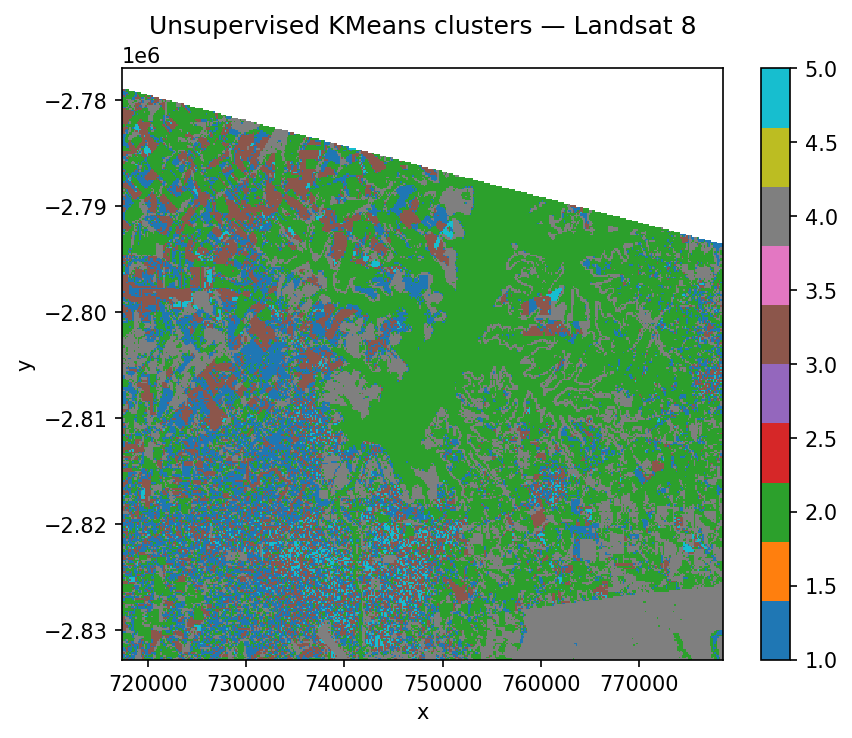

In [5]:
from sklearn.cluster import KMeans

kmeans_pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=6, random_state=0, n_init=10))
])

fig, ax = plt.subplots(dpi=150, figsize=(6, 5))
with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as landsat_scene:
        cluster_map = fit_predict(landsat_scene, kmeans_pipeline)
        cluster_map.plot(robust=True, ax=ax, cmap="tab10")
ax.set_title("Unsupervised KMeans clusters — Landsat 8")
plt.tight_layout(pad=1)
plt.show()

Best score : 0.9384615384615385
Best params: {'pca__n_components': 2, 'scaler__with_std': True}


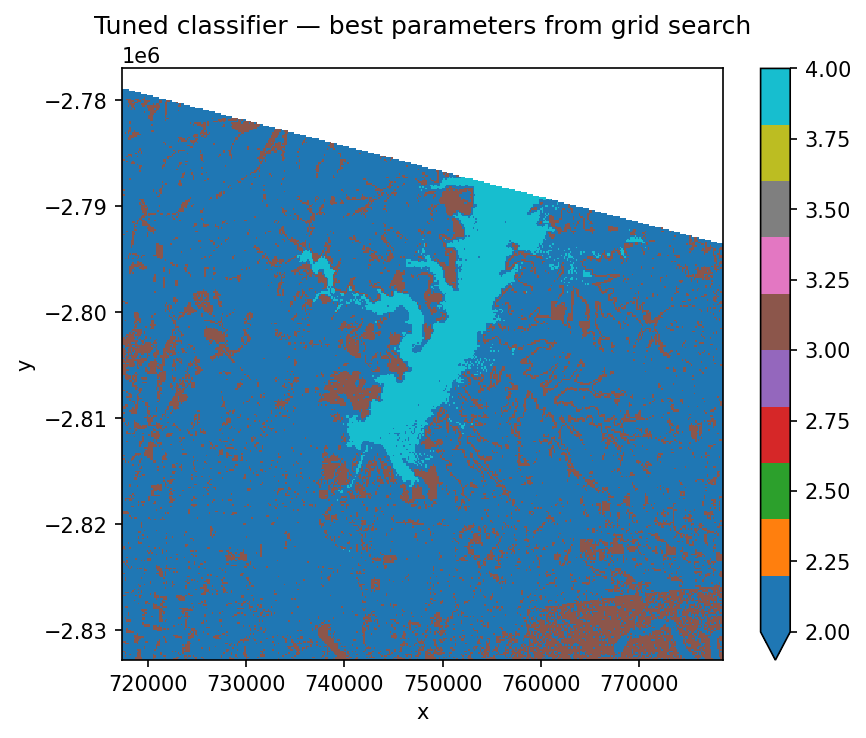

In [6]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn_xarray.model_selection import CrossValidatorWrapper

landcover_pipeline = Pipeline([
    ("scaler",     StandardScaler()),
    ("pca",        PCA()),
    ("classifier", GaussianNB()),
])

xarray_aware_splitter = CrossValidatorWrapper(KFold())
tuning_search = GridSearchCV(
    landcover_pipeline,
    cv=xarray_aware_splitter,
    scoring="balanced_accuracy",
    param_grid={
        "scaler__with_std":   [True, False],
        "pca__n_components":  [1, 2, 3],
    },
)

fig, ax = plt.subplots(dpi=150, figsize=(6, 5))
with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as landsat_scene:
        feature_cube, training_samples, trained_pipeline = fit(
            landsat_scene, landcover_pipeline, training_polygons, col="lc"
        )

        # training_samples is an (X, y) tuple — unpack with *
        tuning_search.fit(*training_samples)
        print("Best score :", tuning_search.best_score_)
        print("Best params:", tuning_search.best_params_)

        # Apply the winning hyperparameters to the trained pipeline
        trained_pipeline.set_params(**tuning_search.best_params_)
        tuned_landcover_map = predict(landsat_scene, feature_cube, trained_pipeline)
        tuned_landcover_map.plot(robust=True, ax=ax, cmap="tab10")
ax.set_title("Tuned classifier — best parameters from grid search")
plt.tight_layout(pad=1)
plt.show()